In [ ]:
import numpy as np
import pandas as pd
from modelens import RegressionAnalyzer

In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)

In [ ]:
raw_data = pd.read_excel('dataset.xls')
df = raw_data.copy()

#### 1 - EDA + ETL

In [ ]:
df = df.rename(columns={
    "Cement (component 1)(kg in a m^3 mixture)":"Cement",
    "Blast Furnace Slag (component 2)(kg in a m^3 mixture)":"Blast Furnace Slag",
    "Fly Ash (component 3)(kg in a m^3 mixture)":"Fly Ash",
    "Water  (component 4)(kg in a m^3 mixture)":"Water",
    "Superplasticizer (component 5)(kg in a m^3 mixture)":"Super Plasticizer",
    "Coarse Aggregate  (component 6)(kg in a m^3 mixture)":"Coarse Aggregate",
    "Fine Aggregate (component 7)(kg in a m^3 mixture)":"Fine Aggregate",
    "Age (day)":"Age",
    "Concrete compressive strength(MPa, megapascals) ":"Concrete Compressive Strength",
})

In [ ]:
analyzer = RegressionAnalyzer(df,target='Concrete Compressive Strength')

In [ ]:
analyzer.info()

In [ ]:
df = df.drop_duplicates()

In [ ]:
analyzer.reinit(df=df,target='Concrete Compressive Strength')

In [ ]:
analyzer.info()

In [ ]:
df.head()

#### 2 - Comparing Models

In [ ]:
target = 'Concrete Compressive Strength'
X = df.drop(columns=[target])
y = df[target]
features = df.columns.drop(target)
features

In [ ]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import (
    AdaBoostRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LinearRegression,
    Ridge,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    # Linear
    "Linear Regression": LinearRegression(),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge()),
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso()),
    ]),

    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet()),
    ]),

    # Distance / Kernel
    "KNN": Pipeline([
        ("scaler",StandardScaler()),
        ("KNN",KNeighborsRegressor())
    ]),
    "SVR":Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR()),
    ]),

    # Tree
    "Decision Tree": DecisionTreeRegressor(
        random_state=42,
    ),

    # Bagging
    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
    ),

    "Extra Trees": ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1,
    ),

    # Boosting
    "AdaBoost": AdaBoostRegressor(
        random_state=42,
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42,
    ),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        random_state=42,
    ),

    "XGBoost": XGBRegressor(
        random_state=42,
        n_jobs=-1,
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        verbosity=-1,
        n_jobs=-1,
    ),

    "CatBoost": CatBoostRegressor(
        random_state=42,
        verbose=0,
    ),
}
# analyzer.compare_models(models=models,features=features,export_html=True) ==> XGBoost

#### 3 - Evaluate Data

In [ ]:
_,suspicious_features=analyzer.correlation(features=features)

In [16]:
analyzer.vif()

,Feature,VIF
0,Cement,8.872611
1,Blast Furnace Slag,7.961747
6,Fine Aggregate,6.993106
3,Water,6.940178
2,Fly Ash,6.373080
5,Coarse Aggregate,4.971580
4,Super Plasticizer,2.895496
8,Concrete Compressive Strength,2.524132
7,Age,1.606666


In [18]:
analyzer.evaluate_single_feature_removal(features=features,export_html=True)

,Train R2,Test R2,R2 Gap,Train RMSE,Test RMSE,RMSE Gap
All Features,0.6048 ± 0.0082,0.5939 ± 0.0337,0.010897,10.2302 ± 0.1888,10.3356 ± 0.7478,0.105435
Without Fine Aggregate,0.6035 ± 0.0076,0.5934 ± 0.0315,0.010185,10.2465 ± 0.1822,10.3432 ± 0.7252,0.09677
Without Coarse Aggregate,0.6036 ± 0.0079,0.5931 ± 0.0324,0.01057,10.2451 ± 0.1867,10.3468 ± 0.7402,0.101743
Without Super Plasticizer,0.6010 ± 0.0080,0.5903 ± 0.0333,0.010754,10.2787 ± 0.1806,10.3802 ± 0.7168,0.101511
Without Water,0.5989 ± 0.0093,0.5890 ± 0.0384,0.009911,10.3062 ± 0.2063,10.3978 ± 0.8175,0.091689
Without Fly Ash,0.5859 ± 0.0063,0.5759 ± 0.0258,0.009993,10.4717 ± 0.1720,10.5643 ± 0.6814,0.092632
Without Blast Furnace Slag,0.5666 ± 0.0053,0.5560 ± 0.0221,0.01057,10.7138 ± 0.1660,10.8110 ± 0.6596,0.097157
Without Cement,0.5290 ± 0.0053,0.5166 ± 0.0230,0.012448,11.1681 ± 0.1511,11.2768 ± 0.6045,0.108765
Without Age,0.4329 ± 0.0127,0.4166 ± 0.0475,0.016365,12.2537 ± 0.1975,12.3795 ± 0.7532,0.125806


In [20]:
selected_model = XGBRegressor()
analyzer.evaluate_single_feature_removal(model=selected_model,features=features,export_html=True)

,Train R2,Test R2,R2 Gap,Train RMSE,Test RMSE,RMSE Gap
All Features,0.9970 ± 0.0010,0.9338 ± 0.0071,0.063192,0.8666 ± 0.1778,4.1608 ± 0.1912,3.294229
Without Fine Aggregate,0.9968 ± 0.0011,0.9294 ± 0.0083,0.067388,0.9023 ± 0.1917,4.3035 ± 0.3246,3.401283
Without Blast Furnace Slag,0.9969 ± 0.0011,0.9276 ± 0.0070,0.069319,0.8840 ± 0.1935,4.3526 ± 0.1176,3.468608
Without Coarse Aggregate,0.9964 ± 0.0013,0.9272 ± 0.0132,0.069266,0.9440 ± 0.2127,4.3451 ± 0.2855,3.401136
Without Fly Ash,0.9970 ± 0.0011,0.9235 ± 0.0060,0.073492,0.8727 ± 0.2043,4.4786 ± 0.1451,3.605962
Without Super Plasticizer,0.9950 ± 0.0015,0.9229 ± 0.0115,0.072165,1.1279 ± 0.1990,4.4851 ± 0.2767,3.357132
Without Water,0.9968 ± 0.0011,0.9216 ± 0.0063,0.075159,0.9058 ± 0.1864,4.5390 ± 0.2852,3.633197
Without Cement,0.9965 ± 0.0011,0.8951 ± 0.0202,0.101427,0.9391 ± 0.1715,5.2120 ± 0.3713,4.272875
Without Age,0.6712 ± 0.0159,0.3244 ± 0.1016,0.346826,9.3274 ± 0.1987,13.2697 ± 0.7411,3.942282


In [21]:
candidates = suspicious_features
analyzer.evaluate_feature_removal_combinations(model=selected_model,features=features,candidates=candidates,export_html=True)

,Removed Count,Removed Features,Remaining Features,Train R2,Test R2,Train RMSE,Test RMSE
0,0,None,"Cement, Blast Furnace Slag, Fly Ash, Water, Super Plasticizer, Coarse Aggregate, Fine Aggregate, Age",0.9970 ± 0.0010,0.9338 ± 0.0071,0.8666 ± 0.1778,4.1608 ± 0.1912


In [22]:
analyzer.permutation_importance(model=selected_model,export_html=True)

(              feature      R2 decrease
 7                 Age  0.7324 ± 0.0559
 0              Cement  0.5450 ± 0.0580
 3               Water  0.1723 ± 0.0172
 1  Blast Furnace Slag  0.1505 ± 0.0148
 4   Super Plasticizer  0.1042 ± 0.0126
 6      Fine Aggregate  0.0633 ± 0.0086
 5    Coarse Aggregate  0.0249 ± 0.0047
 2             Fly Ash  0.0128 ± 0.0026,
               feature     RMSE increase
 7                 Age  11.1606 ± 0.5424
 0              Cement   9.2133 ± 0.6427
 3               Water   4.1053 ± 0.3106
 1  Blast Furnace Slag   3.7059 ± 0.2775
 4   Super Plasticizer   2.7766 ± 0.2708
 6      Fine Aggregate   1.8405 ± 0.2113
 5    Coarse Aggregate   0.8070 ± 0.1402
 2             Fly Ash   0.4319 ± 0.0823)

In [23]:
analyzer.check_overfitting(model=selected_model)

,Metric,Train Mean,Test Mean,Gap
0,R2,0.997033,0.933842,0.063192
1,RMSE,0.866612,4.160841,3.294229


In [24]:
analyzer.residual_analysis(model=selected_model,export_html=True)

(     Cement  Blast Furnace Slag  Fly Ash   Water  Super Plasticizer  \
 951  152.70              144.70     0.00  178.10               8.00   
 654  122.60              183.90     0.00  203.50               0.00   
 706  153.00              102.00     0.00  192.00               0.00   
 538  480.00                0.00     0.00  192.00               0.00   
 389  500.10                0.00     0.00  200.00               3.00   
 ..      ...                 ...      ...     ...                ...   
 232  213.72               98.05    24.51  181.71               6.86   
 802  339.00                0.00     0.00  185.00               0.00   
 358  277.19               97.82    24.46  160.70              11.19   
 234  213.76               98.06    24.52  181.74               6.65   
 374  376.00                0.00     0.00  214.60               0.00   
 
      Coarse Aggregate  Fine Aggregate  Age     Actual  Predicted  Residual  \
 951             999.7          822.20   28  19.009543 

In [25]:
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5],
}
analyzer.tune_model(model=selected_model,param_grid=param_grid,export_html=True)

,Params,Train R2,Test R2,R2 Gap,Train RMSE,Test RMSE,RMSE Gap,Rank
0,"{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.8}",0.9968 ± 0.0011,0.9417 ± 0.0059,0.055160,0.8927 ± 0.1925,3.9115 ± 0.2506,3.018791,1
1,"{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 500, 'subsample': 0.8}",0.9944 ± 0.0010,0.9416 ± 0.0057,0.052801,1.2080 ± 0.1152,3.9112 ± 0.2037,2.703246,2
2,"{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 500, 'subsample': 0.8}",0.9948 ± 0.0011,0.9411 ± 0.0055,0.053752,1.1589 ± 0.1301,3.9336 ± 0.2686,2.774630,3
3,"{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 500, 'subsample': 1.0}",0.9945 ± 0.0010,0.9406 ± 0.0063,0.053892,1.2054 ± 0.1087,3.9476 ± 0.2463,2.742258,4
4,"{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.8}",0.9965 ± 0.0011,0.9403 ± 0.0052,0.056257,0.9409 ± 0.1759,3.9556 ± 0.1453,3.014735,5
...,...,...,...,...,...,...,...,...
139,"{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.8}",0.8541 ± 0.0031,0.8185 ± 0.0175,0.035581,6.2156 ± 0.0825,6.9083 ± 0.5333,0.692676,140
140,"{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 1.0}",0.8529 ± 0.0036,0.8175 ± 0.0192,0.035366,6.2408 ± 0.0789,6.9260 ± 0.5577,0.685228,141
141,"{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 1.0}",0.8533 ± 0.0040,0.8170 ± 0.0183,0.036257,6.2326 ± 0.0845,6.9372 ± 0.5581,0.704579,142
142,"{'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 1.0}",0.8530 ± 0.0041,0.8169 ± 0.0196,0.036078,6.2392 ± 0.0868,6.9387 ± 0.5793,0.699483,143


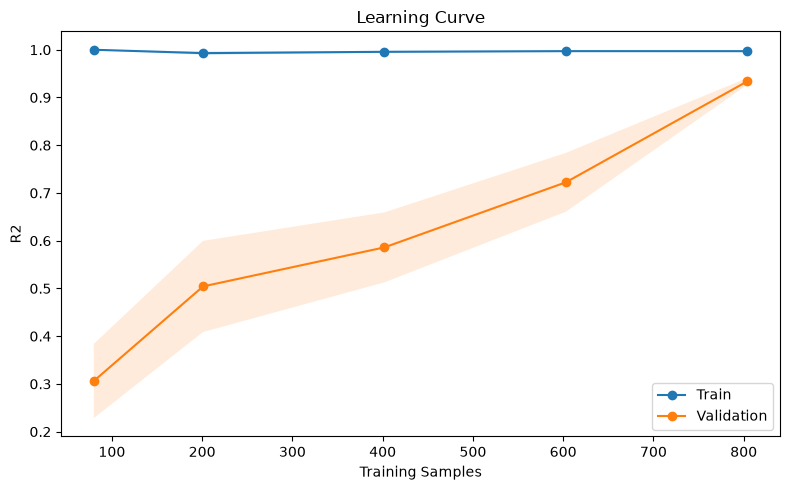

,Train Size,Train R2,Test R2,R2 Gap
0,80,1.0000 ± 0.0000,0.3061 ± 0.0777,0.693854
1,201,0.9929 ± 0.0036,0.5042 ± 0.0955,0.488661
2,402,0.9957 ± 0.0020,0.5860 ± 0.0732,0.409629
3,603,0.9971 ± 0.0013,0.7224 ± 0.0617,0.274706
4,804,0.9970 ± 0.0010,0.9338 ± 0.0071,0.063192


In [26]:
analyzer.learning_curve(model=selected_model)